In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df=pd.read_csv(next(iter(uploaded)))

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
df['gender']=df['gender'].map({"Male" : 0,
                               "Female" : 1})

In [10]:
df['gender'].value_counts()

,count
gender,
0,3555
1,3488


In [11]:
df['Churn']=df['Churn'].map({"No" : 0,
                               "Yes" : 1})

In [12]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
def tenure_stage(t):
    if t <= 3:
        return 'new'
    elif t <= 12:
        return 'early'
    elif t <= 36:
        return 'mid'
    else:
        return 'loyal'

df['tenure_stage'] = df['tenure'].apply(tenure_stage)

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['tenure_stage'] = le.fit_transform(df['tenure_stage'])

In [16]:
df['is_new_customer'] = (df['tenure'] <= 3).astype(int)

In [17]:
df['avg_monthly_from_total'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

In [18]:
df['charge_per_tenure'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

In [19]:
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    df[col + '_bin'] = df[col].map({'Yes': 1, 'No': 0,
                                    'No phone service': 0,
                                    'No internet service': 0})

In [20]:
bin_cols = [c + '_bin' for c in service_cols]
df['total_services'] = df[bin_cols].sum(axis=1)

In [21]:
df['total_services'].head()

,total_services
0,1
1,3
2,3
3,3
4,1


In [22]:
df['has_fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)
df['has_dsl']   = (df['InternetService'] == 'DSL').astype(int)
df['no_internet'] = (df['InternetService'] == 'No').astype(int)
df['has_multiple_lines'] = (df['MultipleLines'] == 'Yes').astype(int)

In [23]:
contract_risk = {'Month-to-month': 2, 'One year': 1, 'Two year': 0}
df['contract_risk_score'] = df['Contract'].map(contract_risk)


In [24]:
df['paperless_billing_bin'] = (df['PaperlessBilling'] == 'Yes').astype(int)

In [25]:
payment_risk = {
    'Electronic check': 3,
    'Mailed check': 2,
    'Bank transfer (automatic)': 1,
    'Credit card (automatic)': 1
}
df['payment_risk_score'] = df['PaymentMethod'].map(payment_risk)

In [26]:
df['has_partner'] = (df['Partner'] == 'Yes').astype(int)
df['has_dependents'] = (df['Dependents'] == 'Yes').astype(int)

In [27]:
df['service_tenure_ratio'] = df['total_services'] / df['tenure'].replace(0, 1)

Churn Prediction


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve


In [29]:
drop_cols = [
    'customerID', 'gender',
    'PhoneService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'InternetService', 'MultipleLines',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'Partner', 'Dependents',
]

df_churn = df.drop(columns=drop_cols, errors='ignore')
df_churn.dropna(inplace=True)

In [30]:
X = df_churn.drop(columns=['Churn'])
y = df_churn['Churn']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [33]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [34]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:56:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [35]:
lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced'
)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001005 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1372
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=4,
               n_estimators=200, random_state=42)

 Logistic Regression
 AUC-ROC  : 0.8368
 Precision: 0.4876
 Recall   : 0.7861
 F1 Score : 0.6018

               precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.72      0.74      1407



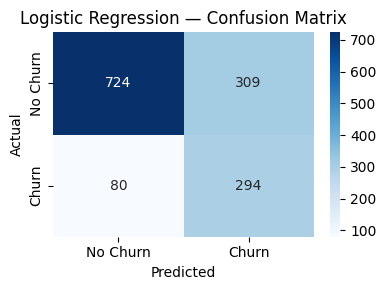

In [36]:
y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

auc_lr  = roc_auc_score(y_test, y_proba_lr)
pre_lr  = precision_score(y_test, y_pred_lr)
re_lr   = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
cm_lr   = confusion_matrix(y_test, y_pred_lr)

print(" Logistic Regression")
print(f" AUC-ROC  : {auc_lr:.4f}")
print(f" Precision: {pre_lr:.4f}")
print(f" Recall   : {re_lr:.4f}")
print(f" F1 Score : {f1_lr:.4f}")
print("\n", classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

plt.figure(figsize=(4,3))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title("Logistic Regression — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

 XGBoost
 AUC-ROC  : 0.8340
 Precision: 0.4983
 Recall   : 0.7888
 F1 Score : 0.6108

               precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



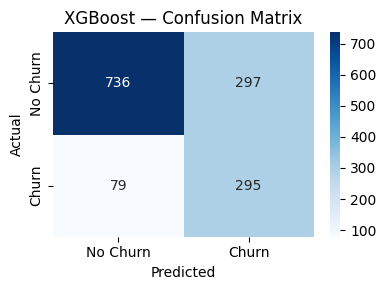

In [37]:
y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
pre_xgb = precision_score(y_test, y_pred_xgb)
re_xgb  = recall_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(" XGBoost")
print(f" AUC-ROC  : {auc_xgb:.4f}")
print(f" Precision: {pre_xgb:.4f}")
print(f" Recall   : {re_xgb:.4f}")
print(f" F1 Score : {f1_xgb:.4f}")
print("\n", classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

plt.figure(figsize=(4,3))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title("XGBoost — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

 LightGBM
 AUC-ROC  : 0.8353
 Precision: 0.5000
 Recall   : 0.7807
 F1 Score : 0.6096

               precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



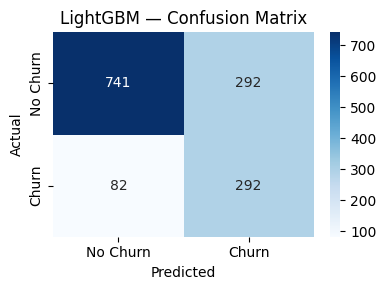

In [38]:
y_pred_lgbm  = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

auc_lgbm = roc_auc_score(y_test, y_proba_lgbm)
pre_lgbm = precision_score(y_test, y_pred_lgbm)
re_lgbm  = recall_score(y_test, y_pred_lgbm)
f1_lgbm  = f1_score(y_test, y_pred_lgbm)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

print(" LightGBM")
print(f" AUC-ROC  : {auc_lgbm:.4f}")
print(f" Precision: {pre_lgbm:.4f}")
print(f" Recall   : {re_lgbm:.4f}")
print(f" F1 Score : {f1_lgbm:.4f}")
print("\n", classification_report(y_test, y_pred_lgbm,target_names=['No Churn', 'Churn']))

plt.figure(figsize=(4,3))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title("LightGBM — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


Model Comparison Summary
                        AUC  Precision  Recall      F1
Model                                                 
Logistic Regression  0.8368     0.4876  0.7861  0.6018
XGBoost              0.8340     0.4983  0.7888  0.6108
LightGBM             0.8353     0.5000  0.7807  0.6096


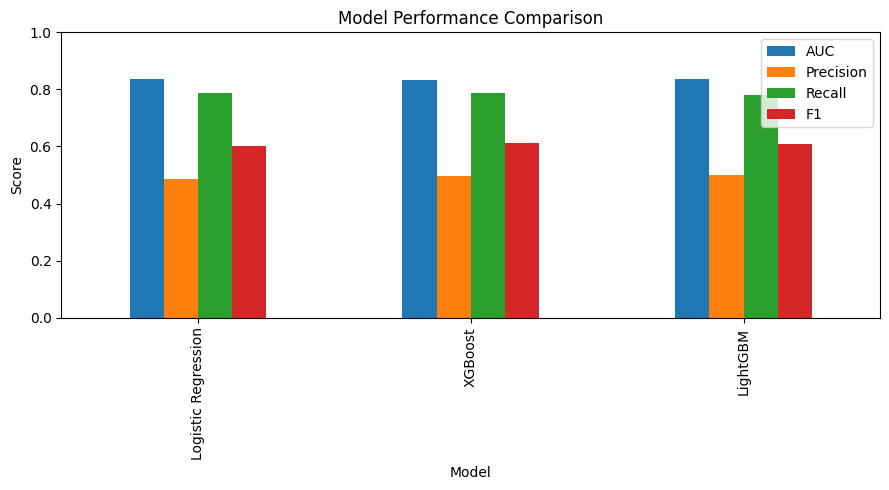

In [39]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'AUC': [auc_lr, auc_xgb, auc_lgbm],
    'Precision': [pre_lr, pre_xgb, pre_lgbm],
    'Recall': [re_lr, re_xgb, re_lgbm],
    'F1': [f1_lr, f1_xgb, f1_lgbm]
})

results_df = results_df.set_index('Model')

print("\nModel Comparison Summary")
print(results_df.round(4).to_string())
results_df.plot(kind='bar',figsize=(9,5),ylim=(0,1))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [40]:
# Best model based on F1 score
best_model_name = results_df['F1'].idxmax()

print("Best Model:", best_model_name)
print("F1 Score:", round(results_df.loc[best_model_name, 'F1'], 4))

Best Model: XGBoost
F1 Score: 0.6108


In [41]:
!pip install shap

In [42]:
import shap

In [43]:
explainer = shap.TreeExplainer(xgb)

In [44]:
shap_values = explainer.shap_values(X_test)

In [45]:
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

print("SHAP values shape:", shap_values_churn.shape)
print("Base value (avg model output):", explainer.expected_value)

SHAP values shape: (1407, 26)
Base value (avg model output): -0.0035148677


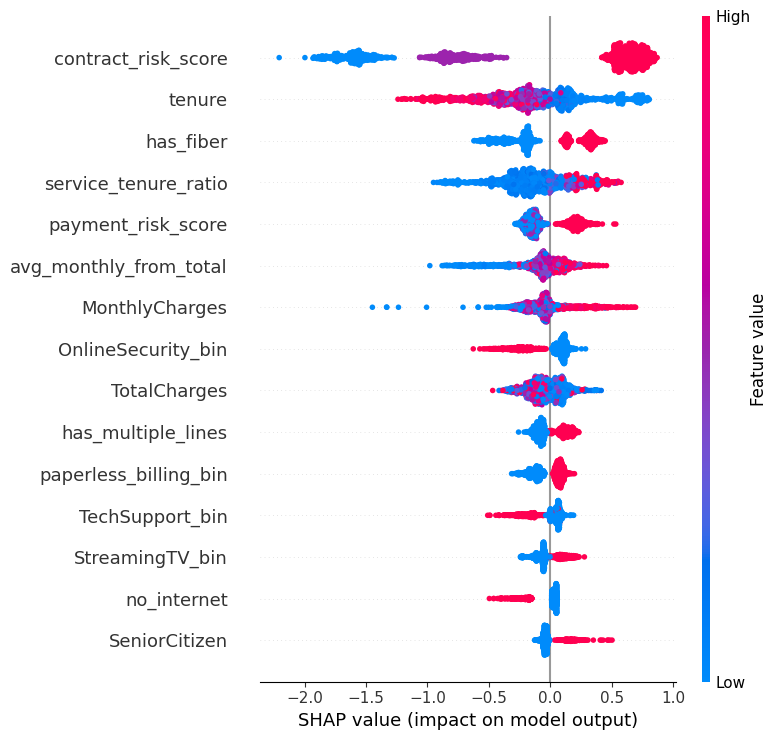

In [46]:
plt.figure()
shap.summary_plot(shap_values_churn,X_test, plot_type="dot", max_display=15,show=True)

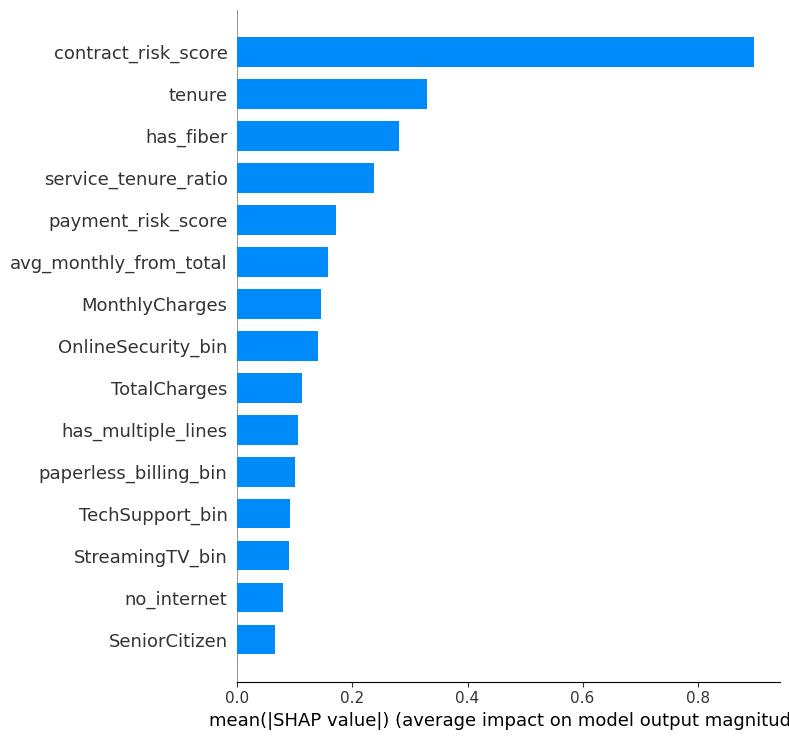

In [47]:
shap.summary_plot(shap_values_churn,X_test,plot_type="bar",max_display=15)

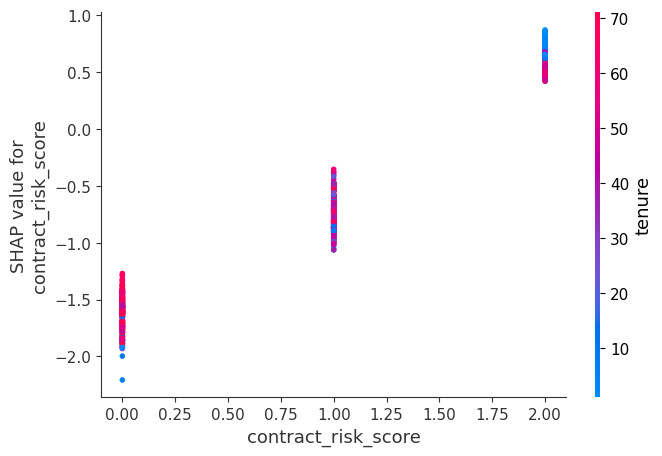

In [48]:
top_feature = 'contract_risk_score'   # change to any feature you want

shap.dependence_plot(
    top_feature,
    shap_values_churn,
    X_test,
    interaction_index='auto',  # auto-picks best interacting feature (colored)
    show=True
)



In [49]:
shap_df = pd.DataFrame(shap_values_churn, columns=X_test.columns)

shap_df['churn_probability'] = xgb.predict_proba(X_test)[:, 1]
shap_df['churn_prediction']  = (shap_df['churn_probability'] >= 0.5).astype(int)

feature_cols_only = X_test.columns.tolist()

shap_df['top_risk_driver']    = shap_df[feature_cols_only].idxmax(axis=1)
shap_df['top_risk_impact']    = shap_df[feature_cols_only].max(axis=1)
shap_df['top_protect_factor'] = shap_df[feature_cols_only].idxmin(axis=1)
shap_df['top_protect_impact'] = shap_df[feature_cols_only].min(axis=1)

In [50]:
shap_df[feature_cols_only].head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,tenure_stage,is_new_customer,avg_monthly_from_total,charge_per_tenure,PhoneService_bin,OnlineSecurity_bin,...,has_fiber,has_dsl,no_internet,has_multiple_lines,contract_risk_score,paperless_billing_bin,payment_risk_score,has_partner,has_dependents,service_tenure_ratio
0,-0.072946,-0.424323,-0.310530,-0.177479,0.002272,0.0,-0.065666,0.0,-0.032638,0.080561,...,-0.200330,0.039387,0.017381,-0.156448,-1.698882,0.051777,-0.127066,-0.029117,-0.092572,-0.320094
1,-0.039562,0.140656,-0.040553,0.041336,0.004799,0.0,-0.071586,0.0,-0.034033,0.132521,...,0.421419,-0.035829,0.047737,0.208122,0.801125,0.110244,-0.151406,0.002198,0.011534,0.259616
2,-0.026616,0.089261,-0.173110,0.291826,0.005374,0.0,-0.105969,0.0,-0.036323,0.129134,...,-0.189566,-0.038394,-0.199016,-0.052045,-1.432233,-0.090665,-0.117166,0.015123,0.022972,0.124682
3,-0.062736,0.331706,-0.249085,-0.101881,-0.008833,0.0,-0.059646,0.0,-0.036016,0.024309,...,-0.480710,-0.210379,-0.290122,-0.073916,0.677822,-0.055949,-0.121486,-0.014822,0.025282,-0.012454
4,-0.019924,-0.622684,0.656763,0.280380,0.003454,0.0,0.428665,0.0,-0.031531,0.161132,...,0.145140,-0.019163,0.029737,0.163885,-1.399916,0.078180,-0.064316,-0.000140,0.026981,-0.031297


Part 4:

In [51]:
!pip install sqlalchemy psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 46.4 MB/s eta 0:00:00


In [52]:
from sqlalchemy import create_engine, text

In [53]:
engine = create_engine("sqlite:///churn_scores.db")

with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("Connected to PostgreSQL")

Connected to PostgreSQL


In [54]:
with engine.connect() as conn:
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS churn_scores (
            customer_id       VARCHAR(50),
            score_date        DATE,
            week_label        VARCHAR(30),
            churn_probability FLOAT,
            churn_prediction  INTEGER,
            risk_tier         VARCHAR(20)
        )
    """))
    conn.commit()

print("Table created")

Table created


In [55]:
import joblib
import pickle

In [56]:
with open('best_model.pkl', 'wb') as file:
    pickle.dump(xgb, file)

In [57]:
from datetime import date

best_model = joblib.load('best_model.pkl')

def assign_risk_tier(prob):
    if prob >= 0.70:   return 'High'
    elif prob >= 0.40: return 'Medium'
    else:              return 'Low'

def run_weekly_pipeline(df_raw, week_label=None):

    if week_label is None:
        week_label = f"week_{date.today()}"

    print(f"\n Running pipeline: {week_label}")


    df = df_raw.copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

    df['is_new_customer']         = (df['tenure'] <= 3).astype(int)
    df['avg_monthly_from_total']  = df['TotalCharges'] / df['tenure'].replace(0, 1)
    df['charge_per_tenure']       = df['TotalCharges'] / df['tenure'].replace(0, 1)

    service_cols = ['PhoneService','OnlineSecurity','OnlineBackup',
                    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
    for col in service_cols:
        df[col+'_bin'] = df[col].map({'Yes':1,'No':0,
                                      'No phone service':0,
                                      'No internet service':0})

    df['total_services']       = df[[c+'_bin' for c in service_cols]].sum(axis=1)
    df['has_fiber']            = (df['InternetService'] == 'Fiber optic').astype(int)
    df['has_dsl']              = (df['InternetService'] == 'DSL').astype(int)
    df['no_internet']          = (df['InternetService'] == 'No').astype(int)
    df['has_multiple_lines']   = (df['MultipleLines'] == 'Yes').astype(int)
    df['contract_risk_score']  = df['Contract'].map({'Month-to-month':2,'One year':1,'Two year':0})
    df['paperless_billing_bin']= (df['PaperlessBilling'] == 'Yes').astype(int)
    df['payment_risk_score']   = df['PaymentMethod'].map({'Electronic check':3,'Mailed check':2,
                                                          'Bank transfer (automatic)':1,
                                                          'Credit card (automatic)':1})
    df['has_partner']          = (df['Partner'] == 'Yes').astype(int)
    df['has_dependents']       = (df['Dependents'] == 'Yes').astype(int)
    df['service_tenure_ratio'] = df['total_services'] / df['tenure'].replace(0, 1)

    feature_cols = [c for c in X_train.columns if c in df.columns]  # same cols as training
    X = df[feature_cols]


    probs       = best_model.predict_proba(X)[:, 1]
    predictions = (probs >= 0.5).astype(int)


    results = pd.DataFrame({
        'customer_id'       : df['customerID'].values,
        'score_date'        : date.today(),
        'week_label'        : week_label,
        'churn_probability' : probs,
        'churn_prediction'  : predictions,
        'risk_tier'         : [assign_risk_tier(p) for p in probs]
    })


    results.to_sql('churn_scores', engine, if_exists='append', index=False)
    print(f" {len(results)} records saved")
    print(f"   High risk  : {(results['risk_tier']=='High').sum()}")
    print(f"   Medium risk: {(results['risk_tier']=='Medium').sum()}")
    print(f"   Low risk   : {(results['risk_tier']=='Low').sum()}")

    return results

In [58]:
# Week 1
r1 = run_weekly_pipeline(df, week_label="week_2024_01_01")

# Week 2
df_w2 = df.copy()
df_w2['tenure']       += 1
df_w2['TotalCharges'] += df_w2['MonthlyCharges']
r2 = run_weekly_pipeline(df_w2, week_label="week_2024_01_08")

# Week 3
df_w3 = df_w2.copy()
df_w3['tenure']       += 1
df_w3['TotalCharges'] += df_w3['MonthlyCharges']
r3 = run_weekly_pipeline(df_w3, week_label="week_2024_01_15")


 Running pipeline: week_2024_01_01
 7043 records saved
   High risk  : 1703
   Medium risk: 1592
   Low risk   : 3748

 Running pipeline: week_2024_01_08
 7043 records saved
   High risk  : 1541
   Medium risk: 1564
   Low risk   : 3938

 Running pipeline: week_2024_01_15


/tmp/ipykernel_4937/3325600115.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)
/tmp/ipykernel_4937/3325600115.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

 7043 records saved
   High risk  : 1477
   Medium risk: 1625
   Low risk   : 3941


In [59]:
history = pd.read_sql("SELECT * FROM churn_scores ORDER BY score_date DESC", engine)
print(f"Total records stored: {len(history)}")
history.head(20)

Total records stored: 21129


,customer_id,score_date,week_label,churn_probability,churn_prediction,risk_tier
0,7590-VHVEG,2026-05-30,week_2024_01_01,0.852042,1,High
1,5575-GNVDE,2026-05-30,week_2024_01_01,0.091522,0,Low
2,3668-QPYBK,2026-05-30,week_2024_01_01,0.657870,1,Medium
3,7795-CFOCW,2026-05-30,week_2024_01_01,0.128337,0,Low
4,9237-HQITU,2026-05-30,week_2024_01_01,0.820940,1,High
5,9305-CDSKC,2026-05-30,week_2024_01_01,0.942854,1,High
6,1452-KIOVK,2026-05-30,week_2024_01_01,0.650961,1,Medium
7,6713-OKOMC,2026-05-30,week_2024_01_01,0.486885,0,Medium
8,7892-POOKP,2026-05-30,week_2024_01_01,0.784614,1,High
9,6388-TABGU,2026-05-30,week_2024_01_01,0.019285,0,Low


In [60]:
INTERVENTION_RULES = {
    'contract_risk_score': {
        'reason': 'On a high-risk month-to-month contract',
        'action': 'Offer discounted 1-year or 2-year contract upgrade'
    },
    'payment_risk_score': {
        'reason': 'Using a high-risk payment method (e.g. electronic check)',
        'action': 'Encourage switch to auto-pay with a small bill credit'
    },
    'is_new_customer': {
        'reason': 'Very new customer (within first 3 months)',
        'action': 'Assign onboarding specialist & check-in call'
    },
    'has_fiber': {
        'reason': 'Fiber optic customer — higher churn segment',
        'action': 'Offer loyalty discount or free service upgrade'
    },
    'paperless_billing_bin': {
        'reason': 'Paperless billing enabled — billing confusion risk',
        'action': 'Send simplified billing summary email'
    },
    'tenure': {
        'reason': 'Short customer tenure — not yet loyal',
        'action': 'Enroll in loyalty rewards program'
    },
    'MonthlyCharges': {
        'reason': 'High monthly charges relative to usage',
        'action': 'Offer a rightsized plan or bundle discount'
    },
    'service_tenure_ratio': {
        'reason': 'Too many services for their tenure — overwhelmed',
        'action': 'Simplify plan or offer service walkthrough session'
    },
    'total_services': {
        'reason': 'Low service adoption — not engaged with product',
        'action': 'Offer free trial of add-on services'
    },
    'has_partner': {
        'reason': 'No partner/family anchor — easier to leave',
        'action': 'Offer family or multi-line discount plan'
    },
}

DEFAULT_ACTION = {
    'reason': 'General churn risk indicators detected',
    'action': 'Schedule proactive customer success call'
}

In [61]:
def get_interventions(customer_idx, shap_vals, X_data, top_n=3):

    prob = best_model.predict_proba(X_data.iloc[[customer_idx]])[0][1]

    if prob >= 0.70:   risk = 'HIGH'
    elif prob >= 0.40: risk = 'MEDIUM'
    else:              risk = 'LOW'

    shap_series = pd.Series(shap_vals[customer_idx], index=X_data.columns)
    top_features = shap_series.sort_values(ascending=False).head(top_n)

    reasons = []
    actions = []

    for feat in top_features.index:
        if feat in INTERVENTION_RULES:
            reasons.append(INTERVENTION_RULES[feat]['reason'])
            actions.append(INTERVENTION_RULES[feat]['action'])
        else:
            reasons.append(DEFAULT_ACTION['reason'])
            actions.append(DEFAULT_ACTION['action'])

    return {
        'customer_id'      : X_data.index[customer_idx],
        'churn_probability': round(prob, 3),
        'risk_level'       : risk,
        'reasons'          : reasons,
        'actions'          : actions
    }

In [62]:
def print_intervention(customer_idx):
    result = get_interventions(customer_idx, shap_values_churn, X_test)

    print(f"  CUSTOMER RETENTION REPORT")
    print(f"  Customer ID       : {result['customer_id']}")
    print(f"  Churn Probability : {result['churn_probability']:.1%}")
    print(f"  Risk Level        : {result['risk_level']}")

    print(f"\n  TOP CHURN REASONS:")
    for i, reason in enumerate(result['reasons'], 1):
        print(f"  {i}. {reason}")

    print(f"\n  RECOMMENDED ACTIONS:")
    for i, action in enumerate(result['actions'], 1):
        print(f"  {i}. {action}")

    print()

print_intervention(0)
print_intervention(5)
print_intervention(10)

  CUSTOMER RETENTION REPORT
  Customer ID       : 974
  Churn Probability : 2.4%
  Risk Level        : LOW

  TOP CHURN REASONS:
  1. General churn risk indicators detected
  2. General churn risk indicators detected
  3. Paperless billing enabled — billing confusion risk

  RECOMMENDED ACTIONS:
  1. Schedule proactive customer success call
  2. Schedule proactive customer success call
  3. Send simplified billing summary email

  CUSTOMER RETENTION REPORT
  Customer ID       : 445
  Churn Probability : 68.6%
  Risk Level        : MEDIUM

  TOP CHURN REASONS:
  1. On a high-risk month-to-month contract
  2. Fiber optic customer — higher churn segment
  3. High monthly charges relative to usage

  RECOMMENDED ACTIONS:
  1. Offer discounted 1-year or 2-year contract upgrade
  2. Offer loyalty discount or free service upgrade
  3. Offer a rightsized plan or bundle discount

  CUSTOMER RETENTION REPORT
  Customer ID       : 4283
  Churn Probability : 83.9%
  Risk Level        : HIGH

  TOP

In [63]:
def batch_interventions(shap_vals, X_data, risk_filter='HIGH'):
    records = []

    for i in range(len(X_data)):
        result = get_interventions(i, shap_vals, X_data)

        if result['risk_level'] == risk_filter or risk_filter == 'ALL':
            records.append({
                'customer_id'       : result['customer_id'],
                'churn_probability' : result['churn_probability'],
                'risk_level'        : result['risk_level'],
                'reason_1'          : result['reasons'][0],
                'reason_2'          : result['reasons'][1],
                'reason_3'          : result['reasons'][2],
                'action_1'          : result['actions'][0],
                'action_2'          : result['actions'][1],
                'action_3'          : result['actions'][2],
            })

    report_df = pd.DataFrame(records)
    report_df  = report_df.sort_values('churn_probability', ascending=False)

    print(f"{len(report_df)} '{risk_filter}' risk customers found")
    return report_df


# Get all HIGH risk customers
high_risk_report = batch_interventions(shap_values_churn, X_test, risk_filter='HIGH')
high_risk_report.head(10)

362 'HIGH' risk customers found


,customer_id,churn_probability,risk_level,reason_1,reason_2,reason_3,action_1,action_2,action_3
299,3380,0.969,HIGH,On a high-risk month-to-month contract,Short customer tenure — not yet loyal,Too many services for their tenure — overwhelmed,Offer discounted 1-year or 2-year contract upg...,Enroll in loyalty rewards program,Simplify plan or offer service walkthrough ses...
263,1073,0.961,HIGH,On a high-risk month-to-month contract,Too many services for their tenure — overwhelmed,Fiber optic customer — higher churn segment,Offer discounted 1-year or 2-year contract upg...,Simplify plan or offer service walkthrough ses...,Offer loyalty discount or free service upgrade
332,6240,0.959,HIGH,On a high-risk month-to-month contract,Short customer tenure — not yet loyal,Too many services for their tenure — overwhelmed,Offer discounted 1-year or 2-year contract upg...,Enroll in loyalty rewards program,Simplify plan or offer service walkthrough ses...
272,4585,0.957,HIGH,On a high-risk month-to-month contract,Short customer tenure — not yet loyal,Too many services for their tenure — overwhelmed,Offer discounted 1-year or 2-year contract upg...,Enroll in loyalty rewards program,Simplify plan or offer service walkthrough ses...
250,3727,0.952,HIGH,On a high-risk month-to-month contract,Too many services for their tenure — overwhelmed,Fiber optic customer — higher churn segment,Offer discounted 1-year or 2-year contract upg...,Simplify plan or offer service walkthrough ses...,Offer loyalty discount or free service upgrade
153,2631,0.952,HIGH,On a high-risk month-to-month contract,Too many services for their tenure — overwhelmed,Fiber optic customer — higher churn segment,Offer discounted 1-year or 2-year contract upg...,Simplify plan or offer service walkthrough ses...,Offer loyalty discount or free service upgrade
210,383,0.952,HIGH,On a high-risk month-to-month contract,Too many services for their tenure — overwhelmed,Short customer tenure — not yet loyal,Offer discounted 1-year or 2-year contract upg...,Simplify plan or offer service walkthrough ses...,Enroll in loyalty rewards program
349,6839,0.945,HIGH,On a high-risk month-to-month contract,Fiber optic customer — higher churn segment,General churn risk indicators detected,Offer discounted 1-year or 2-year contract upg...,Offer loyalty discount or free service upgrade,Schedule proactive customer success call
276,3085,0.945,HIGH,On a high-risk month-to-month contract,Too many services for their tenure — overwhelmed,General churn risk indicators detected,Offer discounted 1-year or 2-year contract upg...,Simplify plan or offer service walkthrough ses...,Schedule proactive customer success call
25,642,0.943,HIGH,On a high-risk month-to-month contract,Short customer tenure — not yet loyal,Too many services for their tenure — overwhelmed,Offer discounted 1-year or 2-year contract upg...,Enroll in loyalty rewards program,Simplify plan or offer service walkthrough ses...


In [64]:

high_risk_report.to_csv("intervention_report.csv", index=False)
print(" Saved to intervention_report.csv")

print(f"\nTotal high-risk customers : {len(high_risk_report)}")
print(f"\nMost common churn reasons:")
pd.concat([
    high_risk_report['reason_1'],
    high_risk_report['reason_2'],
    high_risk_report['reason_3']
]).value_counts().head(5).to_string()

 Saved to intervention_report.csv

Total high-risk customers : 362

Most common churn reasons:


'On a high-risk month-to-month contract                      362\nFiber optic customer — higher churn segment                 251\nToo many services for their tenure — overwhelmed            143\nShort customer tenure — not yet loyal                       116\nUsing a high-risk payment method (e.g. electronic check)    115'

In [68]:
!pip install gradio plotly -q

Dashboard Example_ AI generated


In [69]:

import gradio as gr
import pandas as pd
import plotly.express as px

customers = pd.DataFrame({
    "customer_id"      : ["9237-HQITU","7892-POOKP","0280-XJGEX","9305-CDSKC","8779-QRDMV","6388-TABGU","3655-SNQYZ"],
    "churn_probability": [0.784,       0.761,       0.743,       0.412,       0.692,       0.121,       0.095],
    "risk_tier"        : ["High",      "High",      "High",      "Medium",    "High",      "Low",       "Low"],
    "top_reason"       : ["Month-to-month contract","High monthly charges","Fiber optic + no security",
                          "New customer","Very new customer","Long tenure","2-year contract"],
    "action"           : ["Offer 1-year contract discount","Suggest cheaper bundle","Add security package offer",
                          "Onboarding call","Welcome discount","No action needed","No action needed"],
})

def get_charts():
    # Donut chart
    fig1 = px.pie(customers, names="risk_tier", hole=0.5, title="Risk segmentation",
                  color="risk_tier",
                  color_discrete_map={"High":"#E24B4A","Medium":"#EF9F27","Low":"#639922"})

    # Bar chart
    fig2 = px.bar(customers.sort_values("churn_probability"),
                  x="churn_probability", y="customer_id",
                  orientation="h", title="Churn probability per customer",
                  color="risk_tier",
                  color_discrete_map={"High":"#E24B4A","Medium":"#EF9F27","Low":"#639922"})
    fig2.update_layout(showlegend=False)

    return fig1, fig2

def get_customer_detail(cid):
    row = customers[customers["customer_id"] == cid].iloc[0]
    detail = f"""
### {cid}
| Field | Value |
|---|---|
| Churn probability | {row.churn_probability:.1%} |
| Risk tier | {row.risk_tier} |
| Top reason | {row.top_reason} |
| Recommended action | {row.action} |
"""
    return detail

with gr.Blocks(title="Churn Dashboard") as app:

    gr.Markdown("# Churn Analytics Dashboard")

    # KPI row
    with gr.Row():
        gr.Markdown(f"### Total customers\n## {len(customers)}")
        gr.Markdown(f"### High risk\n## {(customers['risk_tier']=='High').sum()}")
        gr.Markdown(f"### Avg churn prob\n## {customers['churn_probability'].mean():.1%}")

    gr.Markdown("---")

    # Charts row
    with gr.Row():
        donut = gr.Plot()
        bar   = gr.Plot()

    # Drill-down
    gr.Markdown("---")
    gr.Markdown("### Customer detail")
    dropdown = gr.Dropdown(choices=customers["customer_id"].tolist(),
                           label="Select customer",
                           value="9237-HQITU")
    detail_box = gr.Markdown()

    # Load charts on start
    app.load(fn=get_charts,          outputs=[donut, bar])
    app.load(fn=get_customer_detail, inputs=dropdown, outputs=detail_box)

    # Update detail on dropdown change
    dropdown.change(fn=get_customer_detail, inputs=dropdown, outputs=detail_box)

app.launch(share=True)   # gives a public link instantly, no token needed

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://85c385eb55bfad2127.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
